In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [4]:
import os

dataset_dir = r"C:\Users\User\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3"

# List all files in the directory
files = os.listdir(dataset_dir)
print(files)  # Check which files exist

['amz_uk_price_prediction_dataset.csv']


In [6]:
import pandas as pd
from pathlib import Path

file_name = "amz_uk_price_prediction_dataset.csv"
file_path = Path(dataset_dir) / file_name

df = pd.read_csv(file_path)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [8]:
df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [ ]:
Part 1: Analyzing Best-Seller Trends Across Product Categories

In [ ]:
Crosstab Analysis

In [12]:
crosstab_result = pd.crosstab(df['category'], df['isBestSeller']).sort_values(by=True, ascending=False)
crosstab_result

isBestSeller,False,True
category,,
Grocery,9008,556
Health & Personal Care,9017,552
Baby,14709,341
Sports & Outdoors,835935,330
Power & Hand Tools,8353,306
...,...,...
Downhill Ski Boots,1284,0
Digital Frames,774,0
Motorbike Chassis,107,0


Grocery category & Health & Personal Care are prevalent

In [ ]:
Statistical Tests

In [ ]:
Chi-square test

In [16]:
from scipy.stats import chi2_contingency
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_result)
chi2_statistic, chi2_p_value

(36540.202700613874, 0.0)

there is a significant association between the categorical variables

In [ ]:
Cramér's V

In [21]:
from scipy.stats.contingency import association
association(crosstab_result, method="cramer")

0.12228294397605641

In [ ]:
very week association between the variables

In [ ]:
Visualizations

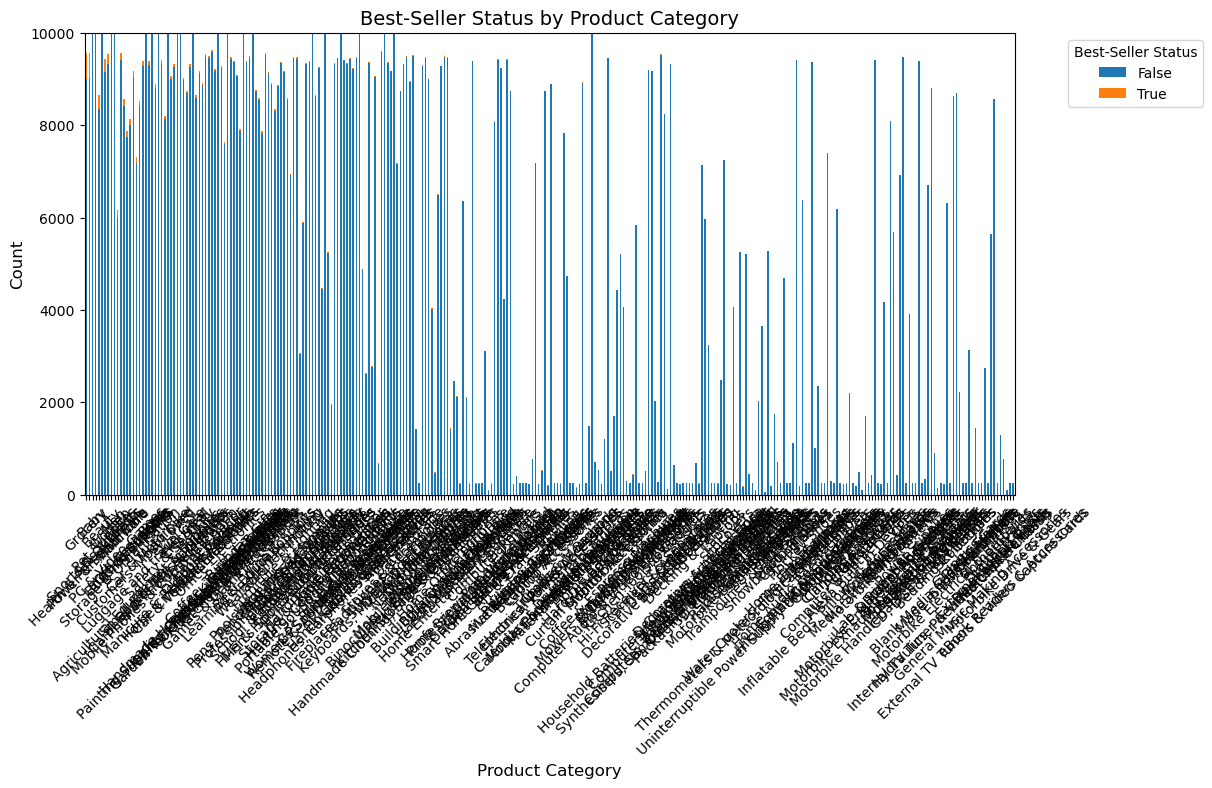

In [29]:
import matplotlib.pyplot as plt

# Define colors manually for better contrast
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Adjust as needed

# Plot stacked bar chart with clearer colors
ax = crosstab_result.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)

# Set y-axis limit
plt.ylim(0, 10000)

# Improve readability
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Best-Seller Status by Product Category", fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Move legend outside
plt.legend(title="Best-Seller Status", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the plot
plt.show()

In [ ]:
Part 2: Exploring Product Prices and Ratings Across Categories and Brands

In [ ]:
0. Preliminary Step: Remove outliers in product prices.

In [37]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define the filtering conditions
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# Display the updated dataframe
df_filtered

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


Violin Plot

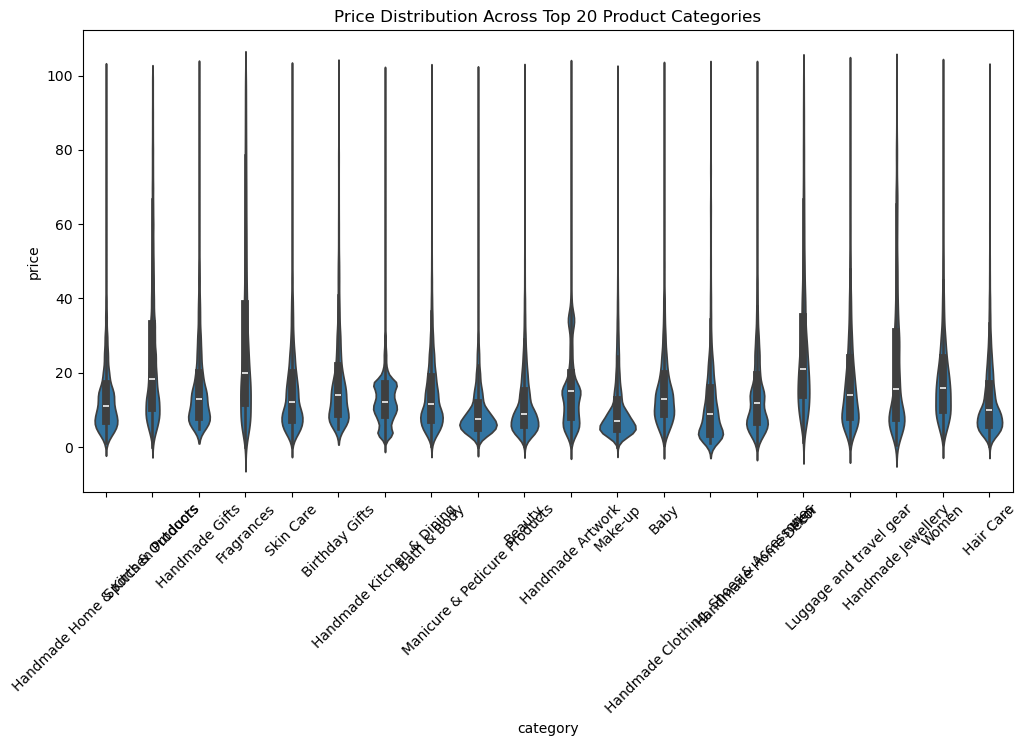

In [46]:
# Compute category counts
category_counts = df_filtered['category'].value_counts()

# Select top 20 categories based on count
top_categories = category_counts.head(20).index

# Filter dataframe to include only products in top 20 categories
df_filtered_1 = df_filtered[df_filtered['category'].isin(top_categories)]

# Plot violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='category', y='price', data=df_filtered_1)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title("Price Distribution Across Top 20 Product Categories")
plt.show()

In [50]:
highest_median_category = df_filtered_1.groupby('category')['price'].median().idxmax()
highest_median_price = df_filtered_1.groupby('category')['price'].median().max()

print(f"Category with highest median price: {highest_median_category}, Median Price: {highest_median_price}")

Category with highest median price: Men, Median Price: 20.99


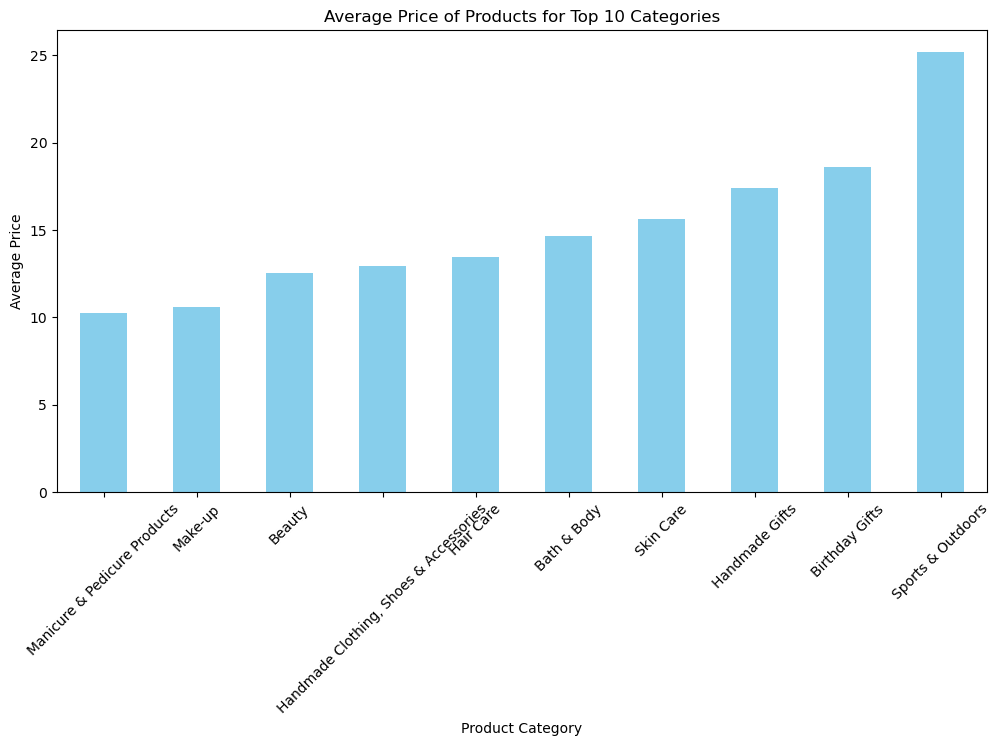

In [52]:
# Compute category counts and select the top 10 categories
top_categories = df_filtered['category'].value_counts().head(10).index

# Filter dataframe to include only products in the top 10 categories
df_filtered_1 = df_filtered[df_filtered['category'].isin(top_categories)]

# Compute the average price per category
avg_prices = df_filtered_1.groupby('category')['price'].mean()

# Plot the bar chart
plt.figure(figsize=(12, 6))
avg_prices.sort_values().plot(kind='bar', color='skyblue')
plt.xlabel("Product Category")
plt.ylabel("Average Price")
plt.title("Average Price of Products for Top 10 Categories")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [54]:
highest_avg_category = df.groupby('category')['price'].mean().idxmax()
highest_avg_price = df.groupby('category')['price'].mean().max()

print(f"Category with highest average price: {highest_avg_category}, Average Price: {highest_avg_price}")

Category with highest average price: Laptops, Average Price: 1087.987826986755


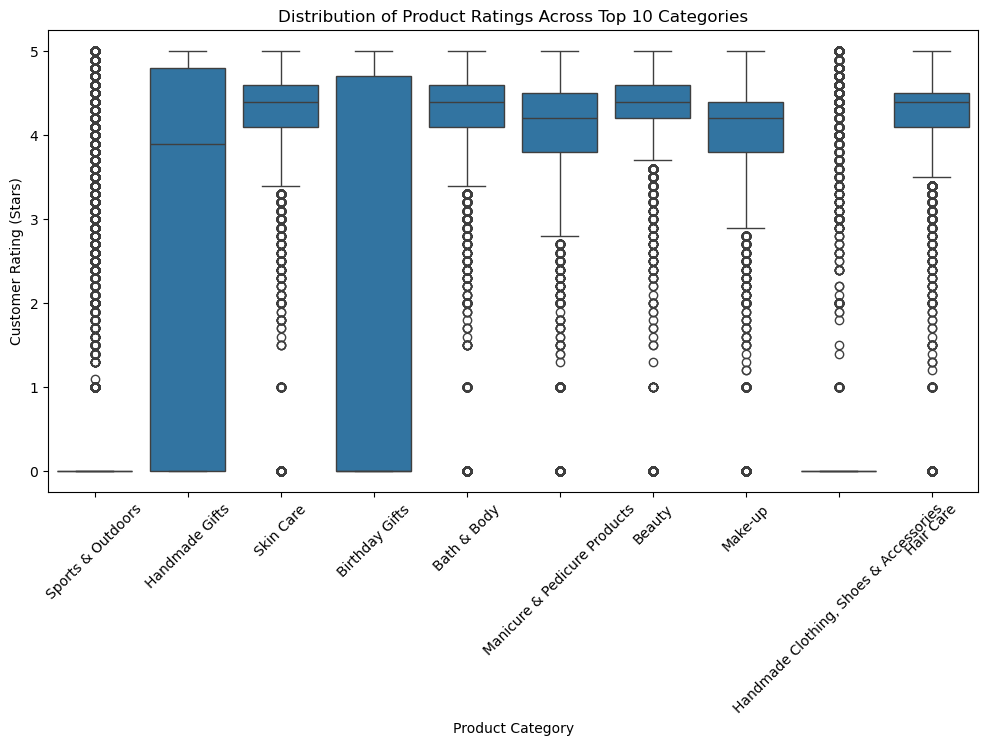

In [58]:
# Plot box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='stars', data=df_filtered_1)
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.title("Distribution of Product Ratings Across Top 10 Categories")
plt.ylabel("Customer Rating (Stars)")
plt.xlabel("Product Category")
plt.show()

In [60]:
highest_median_category = df.groupby('category')['stars'].median().idxmax()
highest_median_rating = df.groupby('category')['stars'].median().max()

print(f"Category with highest median rating: {highest_median_category}, Median Rating: {highest_median_rating}")

Category with highest median rating: Computer Memory, Median Rating: 4.7


In [ ]:
Part 3: Investigating the Interplay Between Product Prices and Ratings

In [62]:
df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [ ]:
Calculate the correlation coefficient between price and stars.

In [64]:
# Compute Pearson correlation coefficient
correlation = df['price'].corr(df['stars'])

print(f"Correlation between price and stars: {correlation}")

Correlation between price and stars: -0.1249067326214861


A correlation of -0.125 suggests a weak negative relationship between price and ratings.

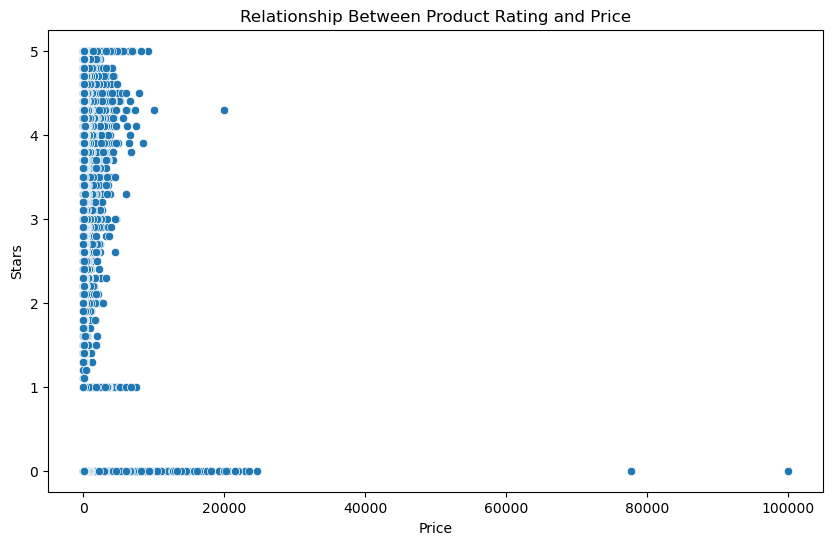

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['price'], y=df['stars'])

# Labels and title
plt.xlabel("Price")
plt.ylabel("Stars")
plt.title("Relationship Between Product Rating and Price")
plt.show()

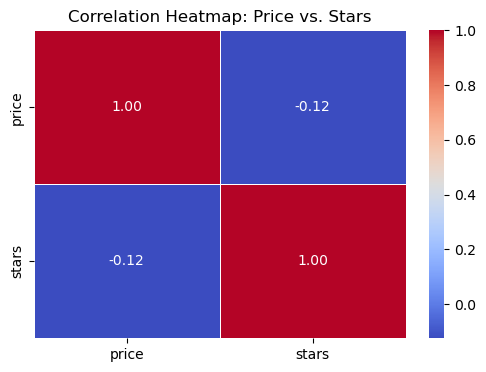

In [75]:
corr_subset = df[['price', 'stars']].corr()

# Plot heatmap for price vs stars correlation
plt.figure(figsize=(6, 4))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Price vs. Stars")
plt.show()

<Figure size 600x600 with 0 Axes>

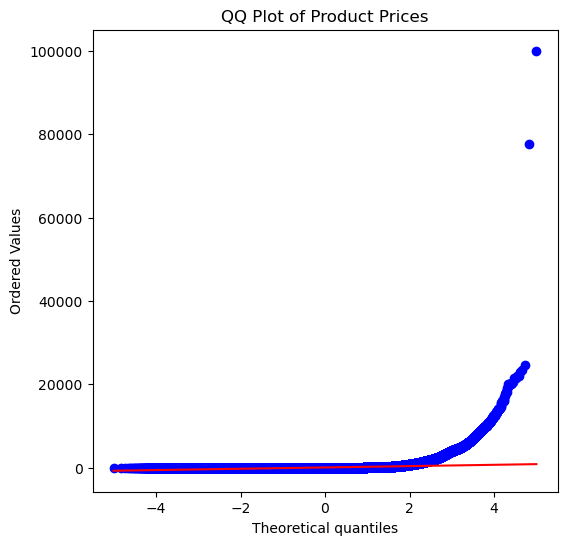

In [79]:
import scipy.stats as st

# Generate QQ plot for product prices
plt.figure(figsize=(6, 6))
st.probplot(df['price'], dist="norm", plot=plt)
plt.title("QQ Plot of Product Prices")
plt.show()